<div style="line-height: 1.6;">

<span style="font-size: 28px; font-weight: bold;">DESM Demonstration Notebook</span><br><br>

<span style="font-size: 20px;">
DESM is a self-supervised deep learning framework for joint channel decoupling and super-resolution reconstruction from single-channel confocal microscopy data. It has two modes: DESM-IO (intensity-only) and DESM-IL (intensity-lifeimte), designed for standard confocal and TCSPC-FLIM systems. 
</span><br><br>

<span style="font-size: 22px; font-weight: bold;">This notebook includes:</span><br><br>

<span style="font-size: 20px;">
1. Real-world <b>DESM-IO</b> inference from single-channel confocal acquisitions.<br>
2. <b>DESM-IL</b> inference from single-channel TCSPC-FLIM acquisitions.<br>
3. <b>DESM-IO</b> application to dynamic microtubule–lysosome imaging using single-channel confocal microscopy.<br>
4. <b>DESM-IL</b> application to dynamic mitochondria–lysosome imaging using single-channel TCSPC-FLIM.<br>
5. Dataset preparation and training on custom data.<br>
6. Evaluation of trained networks.
</span>

</div>

<div style="line-height: 1.6;">

<span style="font-size: 26px; font-weight: bold;">DESM-IO inference on real-world single-channel confocal microscopy data</span><br><br>

<span style="font-size: 20px;">
This demo shows DESM-IO reconstruction for microtubules and mitochondria from single-channel confocal acquisitions, with confocal reference images provided for comparison.
</span>

</div>

  0%|          | 0/1 [00:00<?, ?it/s]

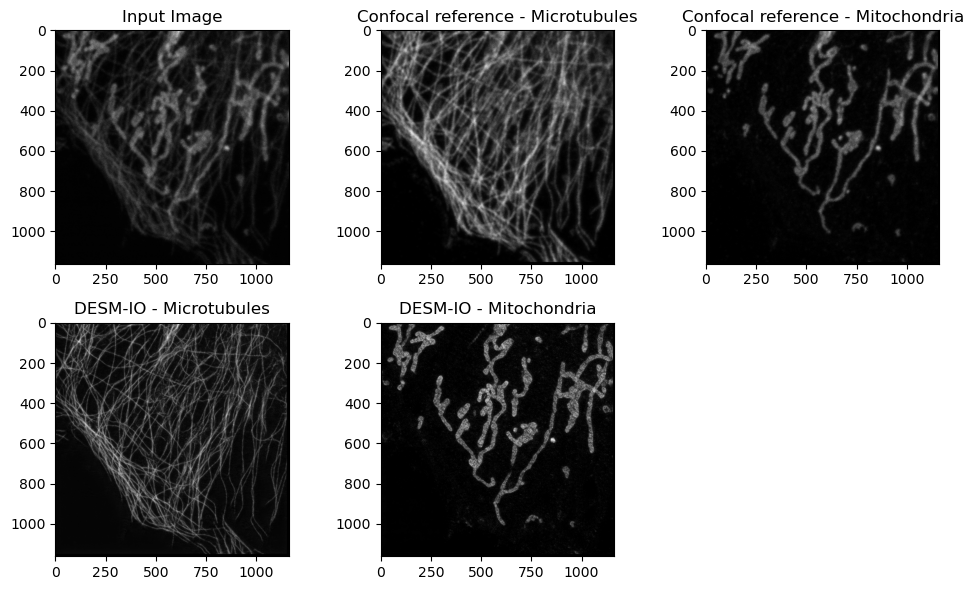

100%|██████████| 1/1 [00:00<00:00,  1.14it/s]


In [1]:
import gc
gc.collect()
import torch
torch.cuda.empty_cache()

from visualization_eval_DESM_IO import DESM_IO_inference_with_reference

# The single-channel confocal images are resized according to experimental value of Leica SP8. 
# If one's image does not suit the pixel size of 20 nm, please down/upsample it. 

read_dir_intensity = r"visualization\real-world data\DESM_IO_Microtubes_Mitochondria_with_reference\data"
weights_dir = r"Trained_models\DESM_IO\DESM_IO_Micro_Mito_228_0.040_4_temp.pth"
save_dir = r'visualization\real-world data\DESM_IO_Microtubes_Mitochondria_with_reference\results'
DESM_IO_inference_with_reference(read_dir=read_dir_intensity, weights_dir=weights_dir, save_dir=save_dir, show_image=True)

<div style="line-height: 1.6;">

<span style="font-size: 26px; font-weight: bold;">DESM-IL inference on real-world single-channel TCSPC-FLIM data</span><br><br>

<span style="font-size: 20px;">
This demo shows DESM-IL reconstruction with lifetime assistance for microtubules, mitochondria, and lysosomes.
</span>

</div>

z8: 100%|██████████| 1/1 [00:02<00:00,  2.04s/it]


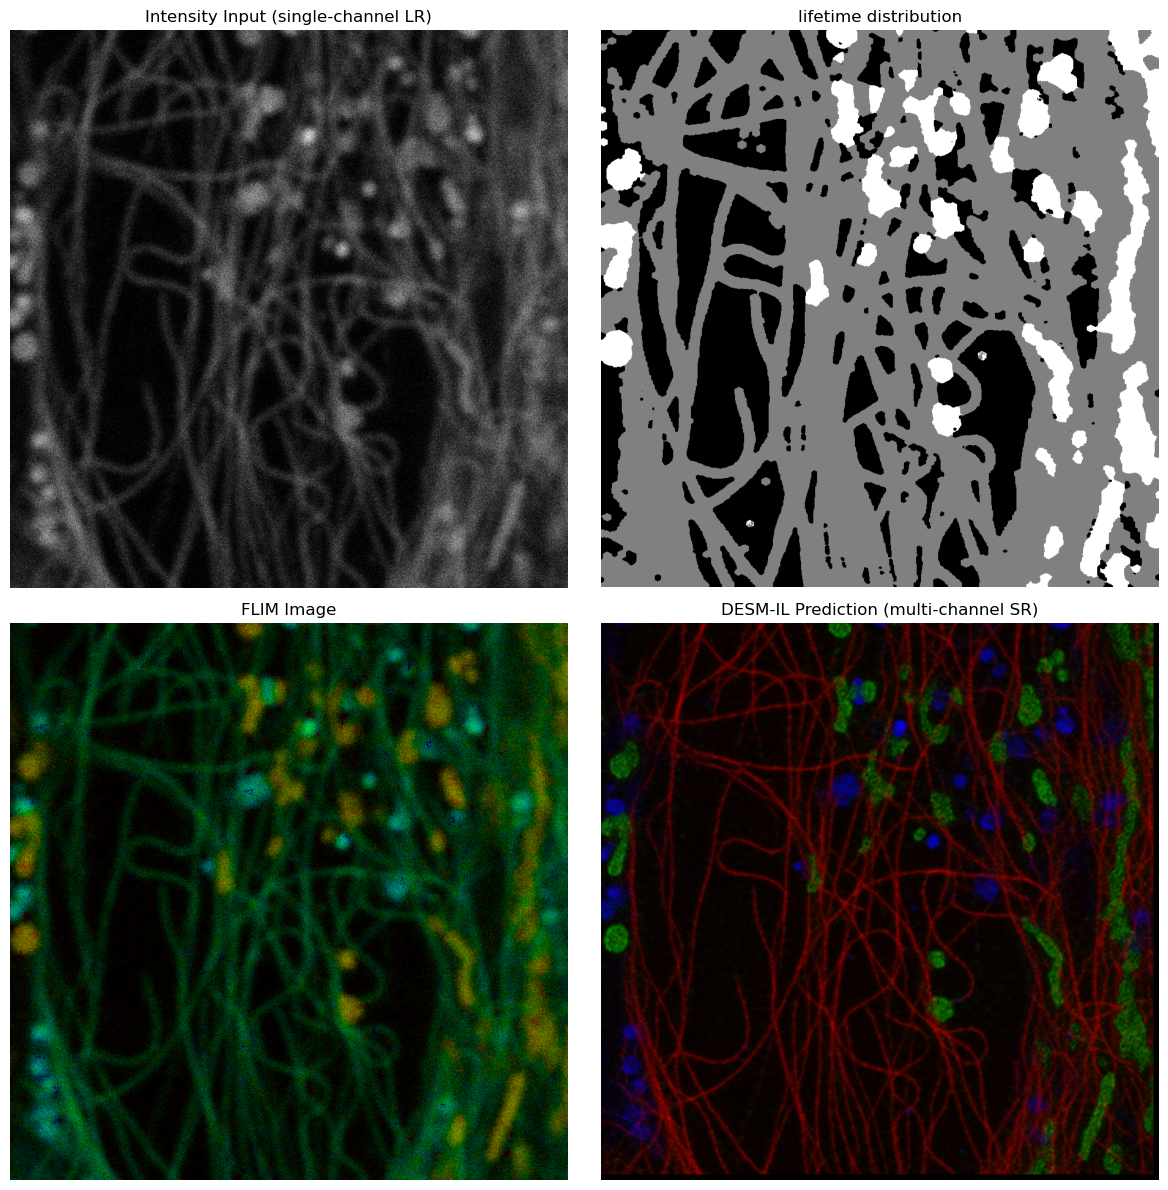

In [3]:
import gc
gc.collect()
import torch
torch.cuda.empty_cache()

from visualization_DESM_IL import DESM_IL_inference

# The single-channel FLIM acquisitions are resized according to our experimental convert table of home-built system. 
# If one's image does not suit the pixel size of 20 nm, please down/upsample it. 

# Micro Mito Lyso
read_dir_intensity = r'visualization\real-world data\DESM_IL_Microtubules_Mitochondria_Lysosomes\Intensity'
save_dir = r'visualization\real-world data\DESM_IL_Microtubules_Mitochondria_Lysosomes\Results'
read_dir_asc = r'visualization\real-world data\DESM_IL_Microtubules_Mitochondria_Lysosomes\ASC'
weights_dir = r"Trained_models\DESM_IL\DESM_IL_Micro_Mito_Lyso_Unet_FLIM_att.pth"
prior_weights_dir = r"Trained_models\DESM_IL\DESM_IO_Prior_Micro_Mito_Lyso.pth"

DESM_IL_inference(read_dir=read_dir_intensity, read_dir_asc=read_dir_asc, weights_dir=weights_dir, prior_weights_dir=prior_weights_dir,
                        save_dir=save_dir, resize_to_const=False, tm_min=0, tm_max=5500, 
                        org_list=['Micro', 'Mito', 'Lyso'], show_image="Layout_1", smooth_iter=2, IO_prior_dilate_iter=0) 

<div style="line-height: 1.6;">

<span style="font-size: 26px; font-weight: bold;">DESM-IO for dynamic microtubule–lysosome imaging from single-channel confocal data</span><br>

<span style="font-size: 20px;">
This demo shows how DESM-IO enhances single-channel confocal imaging of microtubule–lysosome dynamics.
</span>

</div>

In [ ]:
import gc
gc.collect()
import torch
torch.cuda.empty_cache()

from visualization_DESM_IO import DESM_IO_inference

# The single-channel confocal images are resized according to our experimental convert table of home-built system. 
# If one's image does not suit the pixel size of 20 nm, please down/upsample it. 

read_dir = r"visualization\real-world data\DESM_IO_Microtubules_Lysosomes_motion_1\data"
weights_dir = r"Trained_models\DESM_IO\DESM_IO_Micro_Lyso.pth"
save_dir = r'visualization\real-world data\DESM_IO_Microtubules_Lysosomes_motion_1\results'
DESM_IO_inference(read_dir=read_dir, weights_dir=weights_dir, save_dir=save_dir, resize_to_const=False, show_image=True)

File done: Stack0000.tif:   2%|▏         | 1/50 [00:00<00:26,  1.83it/s]

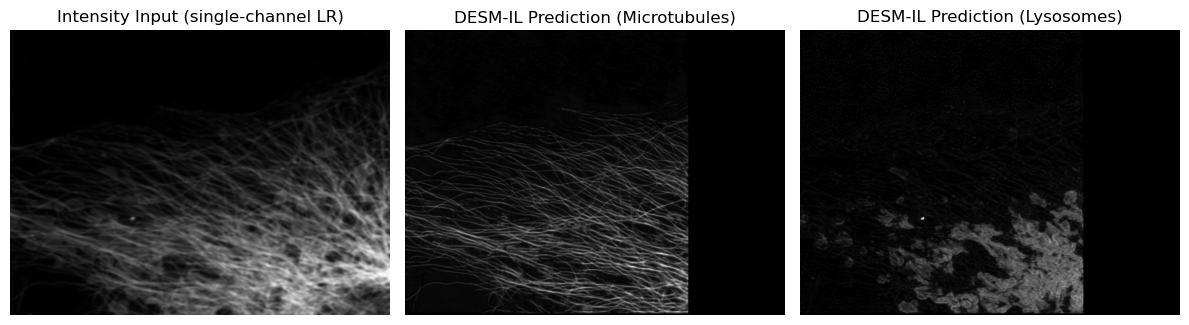

File done: Stack0049.tif: 100%|██████████| 50/50 [00:15<00:00,  3.15it/s]


In [ ]:
import gc
gc.collect()
import torch
torch.cuda.empty_cache()

from visualization_DESM_IO import DESM_IO_inference

# The single-channel confocal images are resized according to our experimental convert table of home-built system. 
# If one's image does not suit the pixel size of 20 nm, please down/upsample it. 

read_dir = r"visualization\real-world data\DESM_IO_Microtubules_Mitochondria_Lysosomes\data"
weights_dir = r"Trained_models\DESM_IO\DESM_IO_Micro_Mito_Lyso_280_0.09_1_temp.pth"
save_dir = r'visualization\real-world data\DESM_IO_Microtubules_Mitochondria_Lysosomes\results'

'''read_dir = r"visualization\real-world data\DESM_IO_Microtubules_Mitochondria_2\data"
weights_dir = r"Trained_models\DESM_IO\DESM_IO_Micro_Mito.pth"
save_dir = r'visualization\real-world data\DESM_IO_Microtubules_Mitochondria_2\results'''
DESM_IO_inference(read_dir=read_dir, weights_dir=weights_dir, save_dir=save_dir, resize_to_const=False, show_image=True)

<div style="line-height: 1.6;">

<span style="font-size: 26px; font-weight: bold;">DESM-IL for dynamic mitochondria–lysosome imaging from single-channel FLIM data</span><br>

<span style="font-size: 20px;">
This demo shows how DESM-IL enhances single-channel FLIM imaging of mitochondria–lysosome dynamics.
</span>

</div>

z8: 100%|██████████| 20/20 [00:28<00:00,  1.42s/it]


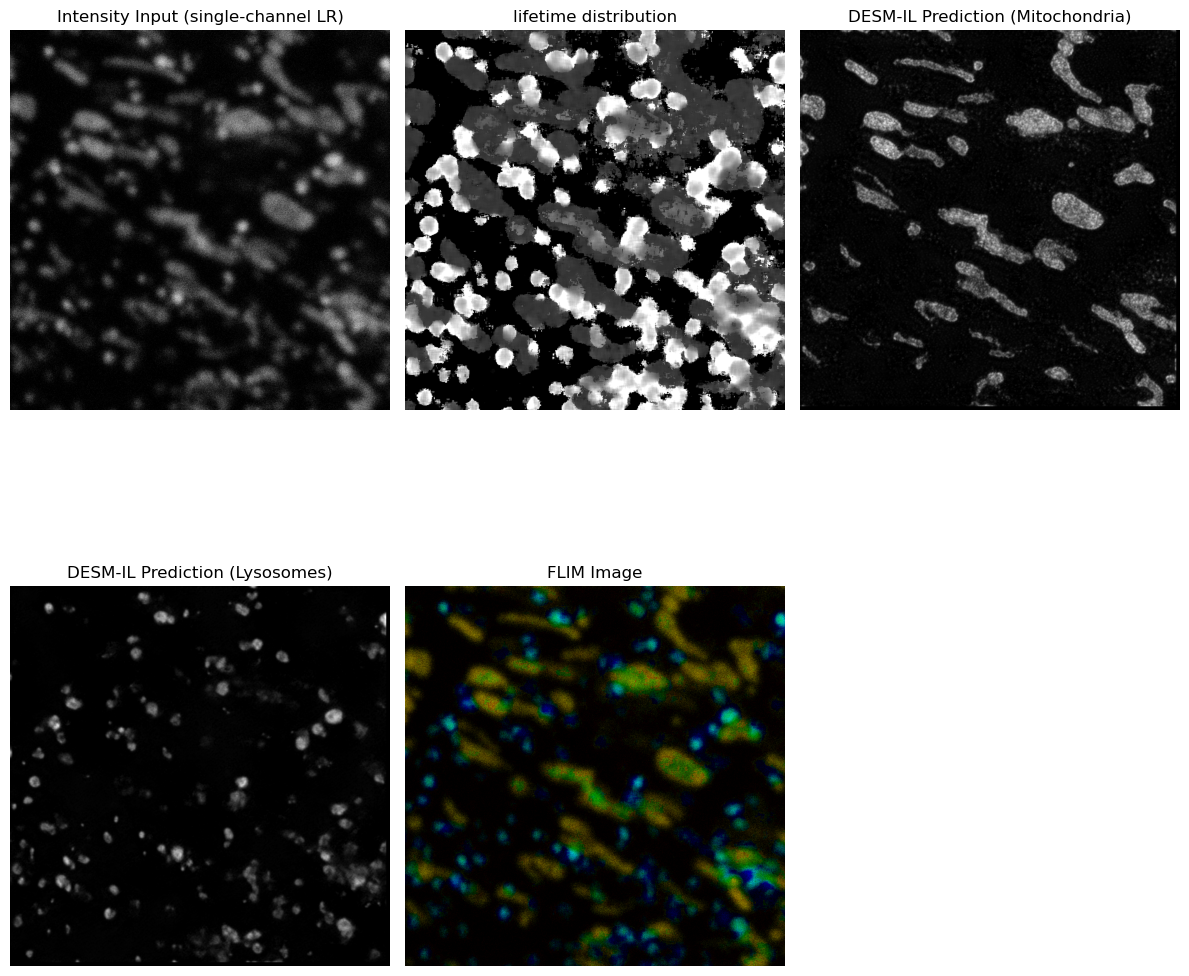

In [2]:
import gc
gc.collect()
import torch
torch.cuda.empty_cache()

from visualization_DESM_IL import DESM_IL_inference

# Mito Lyso dynamics 1
read_dir_intensity = r'visualization\real-world data\DESM_IL_Mitochondria_Lysosomes_motion_1\Intensity'
save_dir = r'visualization\real-world data\DESM_IL_Mitochondria_Lysosomes_motion_1\Results'
read_dir_asc = r'visualization\real-world data\DESM_IL_Mitochondria_Lysosomes_motion_1\ASC'
weights_dir = r"Trained_models\DESM_IL\DESM_IL_Mito_Lyso.pth"
prior_weights_dir = r"Trained_models\DESM_IL\DESM_IO_Prior_Mito_Lyso.pth"

DESM_IL_inference(read_dir=read_dir_intensity, read_dir_asc=read_dir_asc, weights_dir=weights_dir, prior_weights_dir=prior_weights_dir,
                        save_dir=save_dir, resize_to_const=False, tm_min=0, tm_max=5500, 
                        org_list=['Mito', 'Lyso'], show_image="Layout_2", smooth_iter=2, IO_prior_dilate_iter=0) 

<div style="line-height: 1.6;">

<span style="font-size: 26px; font-weight: bold;">Training the network on your own data</span><br><br>

<span style="font-size: 20px;">
This section shows how to prepare your own dataset and train the DESM network on custom data.
</span>

</div>

<span style="font-size: 26px;"> Step 1: Split your data into train / val dataset </span>

Place your data into folders named by the corresponding tags, and put these tag folders under `read_dir`.

Inside each tag folder:

- high-resolution images should be named as `INDEX_STED.tif` or `INDEX_SR.tif`
- low-resolution images, if available, should be named as `INDEX_Confocal.tif` or `INDEX_LR.tif`
- deconvolved images, if available, should be named as `INDEX_deconv.tif`

The data-distribution script will automatically read these files, split them into training and validation sets, and save them into the corresponding output folders.

In [ ]:
import gc
gc.collect()
import torch
torch.cuda.empty_cache()

from dataset.raw_data_gen import distribution

read_dir = r"data\STED_data\deconv_8_bit_smooth"
tags = ['Micro', 'Mito', 'Membrane', 'NPCs', 'Lyso', 'Mito_inner']
save_list = ['Micro', 'Mito', 'Membrane', 'NPCs', 'Lyso', 'Mito_inner']

# Here's save dir for the generated train/val sets.
train_dir_HR = r'data\train_HR'
val_dir_HR = r'data\val_HR'
train_dir_LR = r'data\train_LR'
val_dir_LR = r'data\val_LR'
train_dir_HR_deconv = r'data\train_HR_deconv'
val_dir_HR_deconv = r'data\val_HR_deconv'

# The interval for validation set, e.g., if val_interval=9, then every 9th image will be put in the validation set, and the rest will be put in the training set.
val_interval = 9

# The minimum size of output images. If the input image is smaller than this size, it will be discarded. 
# This is to avoid too small images that may not be useful for training. 
# You can adjust this value according to your data.
min_size = 512

distribution(read_dir=read_dir, train_dir_HR=train_dir_HR, val_dir_HR=val_dir_HR, train_dir_HR_deconv=train_dir_HR_deconv, val_dir_HR_deconv=val_dir_HR_deconv, 
            train_dir_LR=train_dir_LR, val_dir_LR=val_dir_LR, tags=tags, save_list=save_list, val_interval=val_interval, pool2D=False, min_size=min_size)



<span style="font-size: 26px;"> Step 2: Train your network </span>

Adjust the degradation-model settings in the options file, for example in <code>options/train_with_dataset.yml</code>.<br>

The main parameters are listed below:<br>

<b>"degradation_resolution"</b>: target resolution of the single-channel LR image.<br>

<b>"raw_data_resolution"</b>: measured resolution of the raw single-channel SR data.<br>

<b>"noise_level"</b>: Poisson-noise parameter used to simulate the target single-channel LR image.<br>

<b>"average"</b>: number of frame accumulations used in the simulation.<br>

<b>"lifetime_flag"</b>: whether to enable lifetime simulation.<br>

<b>"category"</b>: list of organelle tags to be used. Tags should be introduced in the previous section.<br>

<b>"factor_list"</b>: list of intensity scaling factors for each organelle in the synthesized single-channel LR image.<br>

<b>"read_version"</b>: determines whether training pairs are generated on-the-fly or loaded from prepared data. To pre-generate training pairs, run <code>dataset/gen_datasets.py</code> separately.<br>

<b>"model_decouple_name"</b>: network architecture used for reconstruction, such as <code>"Unet"</code> or <code>"Unet_FLIM_att"</code>.<br>

<b>"validation_date"</b>: name of the output folder used to save training curves, network weights, and validation results.<br>

In [ ]:
import gc
gc.collect()
import torch
torch.cuda.empty_cache()

import os
cwd = os.getcwd()
from options.options import parse
from train_DESM_with_dataset import train

#options of .yml format in "options" folder
opt_path = 'options/train_DESM_with_dataset.yml'
# read options
opt = parse(opt_path=os.path.join(cwd, opt_path))

# Train the network.
train(opt=opt)

<div style="line-height: 1.6;">

<span style="font-size: 26px; font-weight: bold;">Evaluation of DESM-IO on synthetic data</span><br><br>

<span style="font-size: 20px;">
This section evaluates DESM-IO on synthetic data and presents the corresponding reconstruction performance.
</span><br><br>

<span style="font-size: 20px;">
Keep the configuration of Synthetic_eval_DESM_IO.yml to be same as train_with_dataset.yml to assess the network. <br>
Set the weights dir and save dir in net_G/pretrain_dir and save_eval_dir, respectively.
</span>

</div>

In [2]:
import gc
gc.collect()
import torch
torch.cuda.empty_cache()

import os
cwd = os.getcwd()
from options.options import parse
from evaluation_synthetic_IO import evaluate_IO_synthetic

#options of .yml format in "options" folder
opt_path = 'options/Synthetic_eval_DESM_IO.yml'
opt = parse(opt_path=os.path.join(cwd, opt_path))
evaluate_IO_synthetic(opt=opt)

Model name: Unet
initialize network with normal


c:\Users\18923\.conda\envs\chen13d2\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


======================== evaluating ========================


100%|██████████| 200/200 [00:56<00:00,  3.55it/s]

已保存到: visualization\Semi_synthetic_evaluation\DESM_IO\Micro_Mito_228_0_1_20~20temp\metrics.xlsx
Average NRMAE (full image): 0.0401
Average SSIM (full image): 0.6834
Average PCC (full image): 0.9126
Average PSNR (full image): 25.2535
Average NRMAE (foreground): 0.0634
Average SSIM (foreground): 0.6708
Average PCC (foreground): 0.8752
Average PSNR (foreground): 21.9226
Average NRMAE (overlap): 0.1574
Average SSIM (overlap): 0.5276
Average PCC (overlap): 0.5737
Average PSNR (overlap): 17.4461
Average NRMAE (non-overlap): 0.0581
Average SSIM (non-overlap): 0.6588
Average PCC (non-overlap): 0.8886
Average PSNR (non-overlap): 22.4439


{'NRMAE_full': [0.06243816131253417,
  0.030253064862006192,
  0.045578439920154715,
  0.06482384959147307,
  0.02900259189461544,
  0.03764517297963786,
  0.03818980192414251,
  0.057466021238114624,
  0.03399978138946748,
  0.03256218152369488,
  0.03881756296322415,
  0.03275206852284612,
  0.028336895100970316,
  0.0341312463212146,
  0.04148082121964444,
  0.03392884890426903,
  0.04561017230390213,
  0.02981597046959611,
  0.03726031952272785,
  0.038402049204964206,
  0.04495278534699834,
  0.038784541994514476,
  0.062439214465678294,
  0.03431207305604931,
  0.03965607076802706,
  0.05219012220088911,
  0.034735804554792776,
  0.036717861720982806,
  0.04981300818314037,
  0.04815899980889529,
  0.03443924074907453,
  0.028858935884878503,
  0.03456175666956139,
  0.03397959002021242,
  0.02912950922525092,
  0.041347662812344685,
  0.044525783364976534,
  0.02847708950816437,
  0.0503499374881808,
  0.02692142873064983,
  0.039486913792952855,
  0.03302565841977135,
  0.04216

<div style="line-height: 1.6;">

<span style="font-size: 26px; font-weight: bold;">Evaluation of DESM-IL on synthetic data</span><br><br>

<span style="font-size: 20px;">
This section evaluates DESM-IL on synthetic data and presents the corresponding reconstruction performance.
</span><br><br>

<span style="font-size: 20px;">
Keep the configuration of Synthetic_eval_DESM_IL.yml to be same as train_with_dataset.yml to assess the network. <br>
Set the weights dir and save dir in net_G/pretrain_dir and save_eval_dir, respectively.
</span>

</div>

</div>

In [ ]:
import gc
gc.collect()
import torch
torch.cuda.empty_cache()

import os
cwd = os.getcwd()
from options.options import parse
from evaluation_synthetic_IL import evaluate_IL_synthetic

#options of .yml format in "options" folder
opt_path = 'options/Synthetic_eval_DESM_IL.yml'
opt = parse(opt_path=os.path.join(cwd, opt_path))
evaluate_IL_synthetic(opt=opt)

<div style="line-height: 1.6;">

<span style="font-size: 26px; font-weight: bold;">Training/evaluating the network on simulated data</span><br><br>

<span style="font-size: 20px;">
For those might be interested, check the "dataset/gen_simulation.py", "train_DESM_IO_simulation.py", "train_DESM_IL_simulation.py", "evaluation_synthetic_IO.py", and "evaluation_synthetic_IO.py"
</span>

</div>